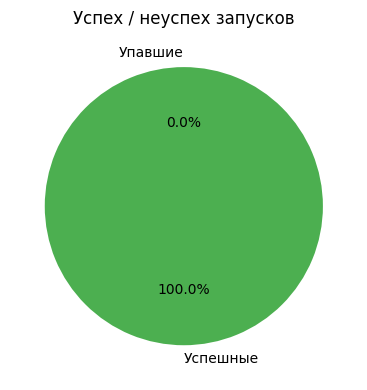

In [13]:
import json
import matplotlib.pyplot as plt

STATS_PATH = "stats.json"

with open(STATS_PATH, encoding="utf-8") as f:
    data = json.load(f)

successful = [r for r in data if r.get("success")]
failed = [r for r in data if not r.get("success")]

fig, ax = plt.subplots(figsize=(4, 4))
ax.pie(
    [len(successful), len(failed)],
    labels=["Успешные", "Упавшие"],
    colors=["#4CAF50", "#F44336"],
    autopct="%1.1f%%",
    startangle=90,
)
ax.set_title("Успех / неуспех запусков")
plt.tight_layout()
plt.show()

In [14]:
roles = [r["role"] for r in successful]
elapsed = [r["total_elapsed_sec"] for r in successful]
scores = [r.get("quality_score") for r in successful]
total_tokens = [r["tokens"]["total_tokens"] for r in successful]

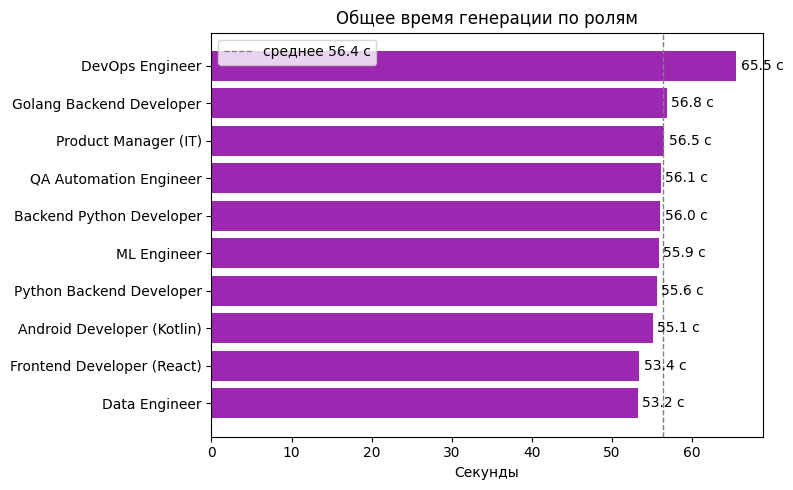

In [15]:
# Общее время по всем запускам — сортировка по убыванию, горизонтальный
pairs = sorted(zip(elapsed, roles), reverse=True)
elapsed_sorted, roles_sorted = zip(*pairs)

avg_elapsed = sum(elapsed) / len(elapsed)

fig, ax = plt.subplots(figsize=(8, max(4, len(roles_sorted) * 0.5)))
bars = ax.barh(list(reversed(roles_sorted)), list(reversed(elapsed_sorted)), color="#9C27B0")
ax.bar_label(bars, fmt="%.1f с", padding=3)
ax.axvline(avg_elapsed, color="gray", linestyle="--", linewidth=1, label=f"среднее {avg_elapsed:.1f} с")
ax.set_title("Общее время генерации по ролям")
ax.set_xlabel("Секунды")
ax.legend()
plt.tight_layout()
plt.show()

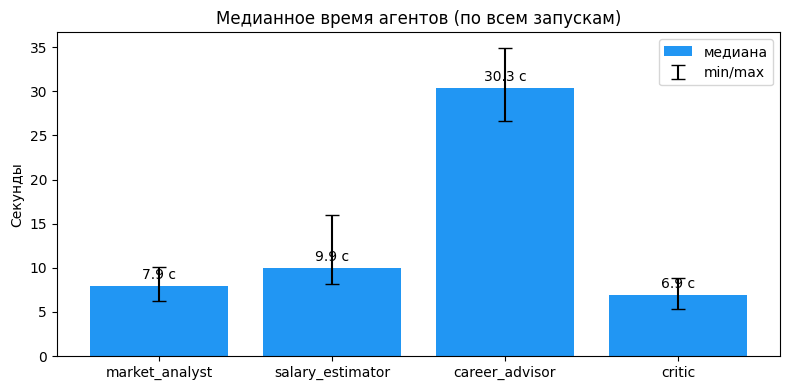

In [18]:
# Среднее время по агентам — по всем запускам
from collections import defaultdict
import statistics

agent_times = defaultdict(list)
for r in successful:
    for agent, t in r.get("agent_timings_sec", {}).items():
        agent_times[agent].append(t)

agents_all = list(agent_times.keys())
medians = [statistics.median(agent_times[a]) for a in agents_all]
mins = [min(agent_times[a]) for a in agents_all]
maxs = [max(agent_times[a]) for a in agents_all]

x = range(len(agents_all))
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(x, medians, color="#2196F3", label="медиана")
ax.bar_label(bars, fmt="%.1f с", padding=3)
ax.errorbar(x, medians,
    yerr=[[(m - mn) for m, mn in zip(medians, mins)],
          [(mx - m) for m, mx in zip(medians, maxs)]],
    fmt="none", color="black", capsize=5, label="min/max")
ax.set_xticks(list(x))
ax.set_xticklabels(agents_all)
ax.set_title("Медианное время агентов (по всем запускам)")
ax.set_ylabel("Секунды")
ax.legend()
plt.tight_layout()
plt.show()

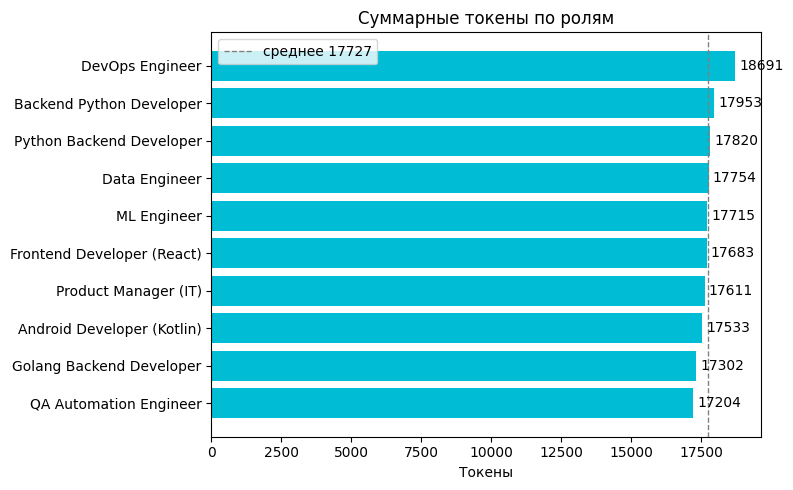

In [16]:
# Суммарные токены по ролям — сортировка по убыванию, горизонтальный
pairs_t = sorted(zip(total_tokens, roles), reverse=True)
tokens_sorted, roles_tokens_sorted = zip(*pairs_t)

avg_tokens = sum(total_tokens) / len(total_tokens)

fig, ax = plt.subplots(figsize=(8, max(4, len(roles_tokens_sorted) * 0.5)))
bars = ax.barh(list(reversed(roles_tokens_sorted)), list(reversed(tokens_sorted)), color="#00BCD4")
ax.bar_label(bars, padding=3)
ax.axvline(avg_tokens, color="gray", linestyle="--", linewidth=1, label=f"среднее {avg_tokens:.0f}")
ax.set_title("Суммарные токены по ролям")
ax.set_xlabel("Токены")
ax.legend()
plt.tight_layout()
plt.show()

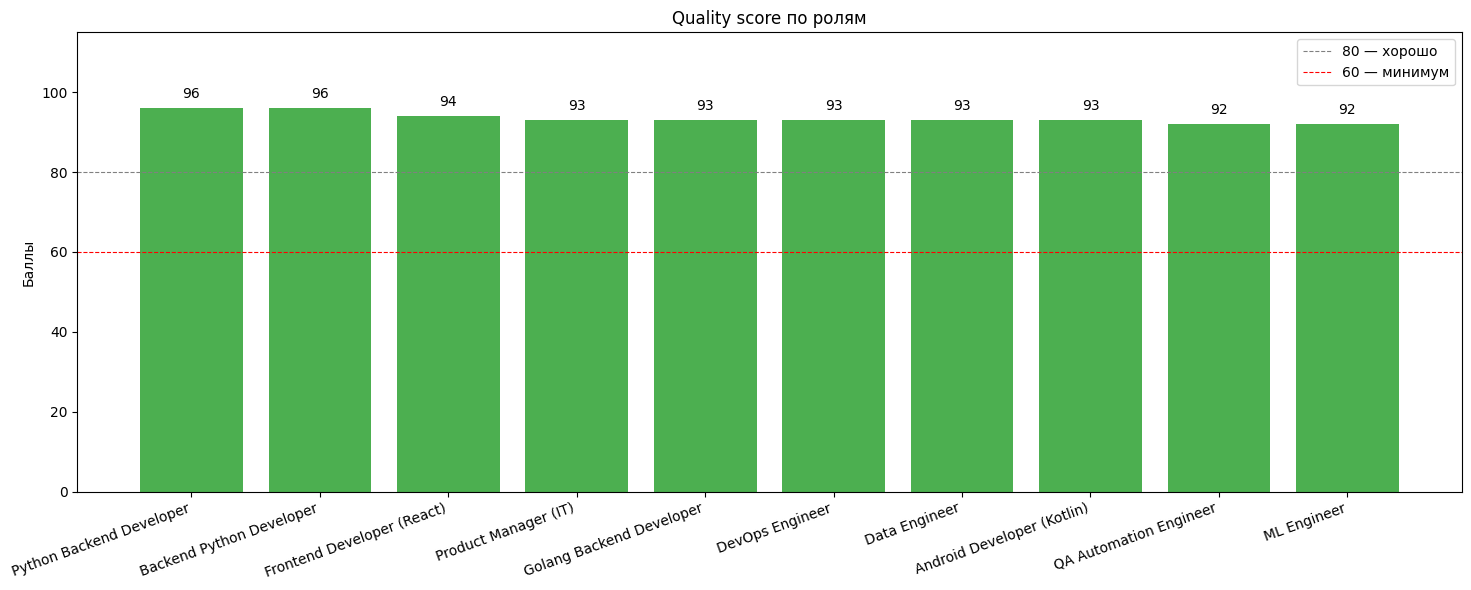

In [17]:
# Quality score — сортировка по убыванию, увеличенное окно
pairs_s = sorted(zip(scores, roles), reverse=True)
scores_sorted, roles_scores_sorted = zip(*pairs_s)

colors = ["#4CAF50" if s >= 80 else "#FF9800" if s >= 60 else "#F44336" for s in scores_sorted]
fig, ax = plt.subplots(figsize=(max(6, len(roles_scores_sorted)*1.5), 6))
bars = ax.bar(roles_scores_sorted, scores_sorted, color=colors)
ax.bar_label(bars, padding=5)
ax.set_ylim(0, 115)
ax.axhline(80, color="gray", linestyle="--", linewidth=0.8, label="80 — хорошо")
ax.axhline(60, color="red", linestyle="--", linewidth=0.8, label="60 — минимум")
ax.set_title("Quality score по ролям")
ax.set_ylabel("Баллы")
ax.legend()
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()